# Slow Dynamics and High Variability in Networks with Clustered Connections




# Converting difference of exponential filter to an ODE

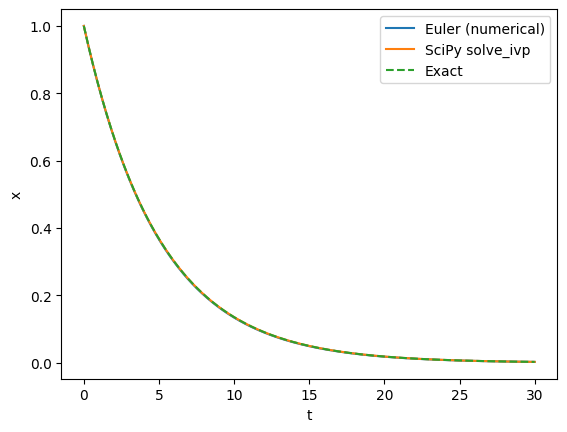

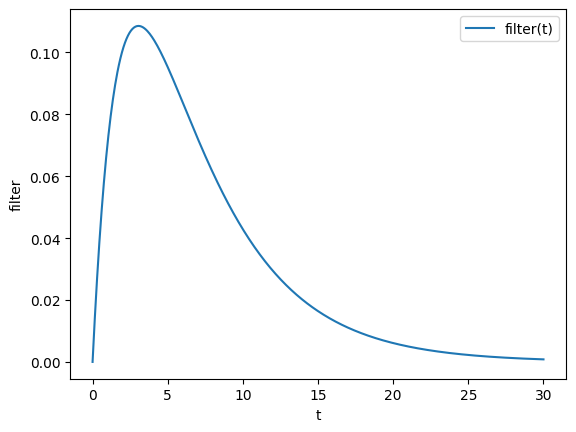

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def x_prime(x, t1):
    return -x / t1

def g_prime(g, x, t2):
    return (x - g) / t2

def filter(t, t1, t2):
    return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

def euler_solve(x0, t, t1):
    """Simple Euler method for x' = -x/t1."""
    x = np.zeros_like(t)
    x[0] = x0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
    return x

t1 = 5.0
x0 = 1.0
t = np.linspace(0.0, 30.0, 600)

x_num = euler_solve(x0, t, t1)

sol = solve_ivp(
    lambda tau, y: x_prime(y, t1),
    t_span=(t[0], t[-1]),
    y0=[x0],
    t_eval=t,
)
x_scipy = sol.y[0]

x_exact = x0 * np.exp(-t / t1)

fig, ax = plt.subplots()
ax.plot(t, x_num, label="Euler (numerical)")
ax.plot(t, x_scipy, label="SciPy solve_ivp")
ax.plot(t, x_exact, "--", label="Exact")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.legend()
plt.show()

# Plot the filter for a sample t2.
t2 = 2.0

fig, ax = plt.subplots()
ax.plot(t, filter(t, t1, t2), label="filter(t)")
ax.set_xlabel("t")
ax.set_ylabel("filter")
ax.legend()
plt.show()


# Initialize default model parameters

In [88]:
from dataclasses import dataclass
from brian2 import ms, second, volt
from typing import Tuple
import numpy as np

@dataclass
class ClusterParams:
    enabled: bool = False
    R_ee: float = 1.0 # ratio of p_in / p_out. 1.0 implies no clustering
    cluster_size: int = 80 # num neurons in each cluster
    weight_scaling_factor: float = 1.9 # ƒactor to scale excitatory synaptic weight for in-cluster connections

    # TODO: Is this correct?
    def calculate_p_in_out(self, N_E: int, p_avg: float) -> Tuple[float, float]:
        # Use within-cluster pair probability (exclude self)
        p_same = (self.cluster_size - 1) / (N_E - 1)

        # Enforce: p_avg = p_same * p_in + (1 - p_same) * p_out
        # and p_in = R_ee * p_out
        denom = p_same * self.R_ee + (1 - p_same)
        p_out = p_avg / denom
        p_in = self.R_ee * p_out

        return p_in, p_out


class ModelParams:
    """Parameters for the clustered network model."""
    
    def __init__(
        self,
        # Network size
        N_E=4000,              # number of excitatory neurons
        N_I=1000,              # number of inhibitory neurons
        N_ref=5000,            # reference network size (for weight scaling)
        seed=42,               # random seed
        # Neuron parameters
        refractory_t=5*ms,     # refractory period
        tau_e=15*ms,           # membrane time constant for E neurons
        tau_i=10*ms,           # membrane time constant for I neurons
        Vt=1,                  # spike threshold
        Vr=0,                  # reset potential
        # Synaptic time constants
        tau_1=1*ms,               # exponential filter time constant 1
        tau2_e=3*ms,             # exponential filter time constant 2 (excitatory)
        tau2_i=2*ms,             # exponential filter time constant 2 (inhibitory)
        # Reference synaptic weights (calibrated for N=5000)
        j_ee_ref=0.024,        # E -> E
        j_ie_ref=0.014,        # E -> I 
        j_ei_ref=-0.045,       # I -> E (negative for inhibition)
        j_ii_ref=-0.057,       # I -> I
        # Connection probabilities
        p_conn_e=0.2,          # E -> E connection probability
        p_conn_i=0.5,          # connection probability involving I
        # Mean equilibrium
        mu_e_range=(1.1, 1.2),    # external input range for E neurons
        mu_i_range=(1.0, 1.05),   # external input range for I neurons
        # Initial inputs
        n_input=10,            # number of input spike sources
        # Simulation parameters
        dt=0.1*ms,             # integration timestep
        analysis_start_t=1.5*second, # time to start statistical analysis
        analysis_window_t=1.5*second, # time window to perform statistical analysis
        duration=3*second,     # simulation duration
        # Plotting
        voltage_scale=15*volt, # for converting to physical units
    ):
        self.N_E = N_E
        self.N_I = N_I
        self.N_ref = N_ref
        self.seed = seed
        self.refractory_t = refractory_t
        self.tau_m_e = tau_e
        self.tau_m_i = tau_i
        self.Vt = Vt
        self.Vr = Vr
        self.tau1 = t1
        self.tau2_e = tau2_e
        self.tau2_i = tau2_i
        self.j_ee_ref = j_ee_ref
        self.j_ei_ref = j_ei_ref
        self.j_ie_ref = j_ie_ref
        self.j_ii_ref = j_ii_ref
        self.p_conn_e = p_conn_e
        self.p_conn_i = p_conn_i
        self.mu_e_range = mu_e_range
        self.mu_i_range = mu_i_range
        self.n_input = n_input
        self.dt = dt
        self.analysis_start_t = analysis_start_t
        self.analysis_window_t = analysis_window_t
        self.duration = duration
        self.voltage_scale = voltage_scale
    
    @property
    def N_total(self):
        """Total number of neurons."""
        return self.N_E + self.N_I
    
    @property
    def scaled_weights(self):
        """
        Scale synaptic weights based on network size.
        
        Weights scale as 1/sqrt(N) to maintain constant variance 
        of total synaptic input as network size changes.
        """
        scale_factor = np.sqrt(self.N_ref / self.N_total) # TODO: Not sure about using N_ref here
        return (
            self.j_ee_ref * scale_factor,
            self.j_ei_ref * scale_factor,
            self.j_ie_ref * scale_factor,
            self.j_ii_ref * scale_factor,
        )
    
    def get_rng(self):
        """Return a numpy random generator with the configured seed."""
        return np.random.default_rng(seed=self.seed)

# A base, homogenous model

WARNING    The object 'synapses_12' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_10247/1280417346.py', line 77, in <module>
    S_ie = Synapses(E, I, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt) [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses_13' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_10247/1280417346.py', line 79, in <module>
    S_ei = Synapses(I, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt) [brian2.core.base.u

TypeError: 'Axes' object is not subscriptable

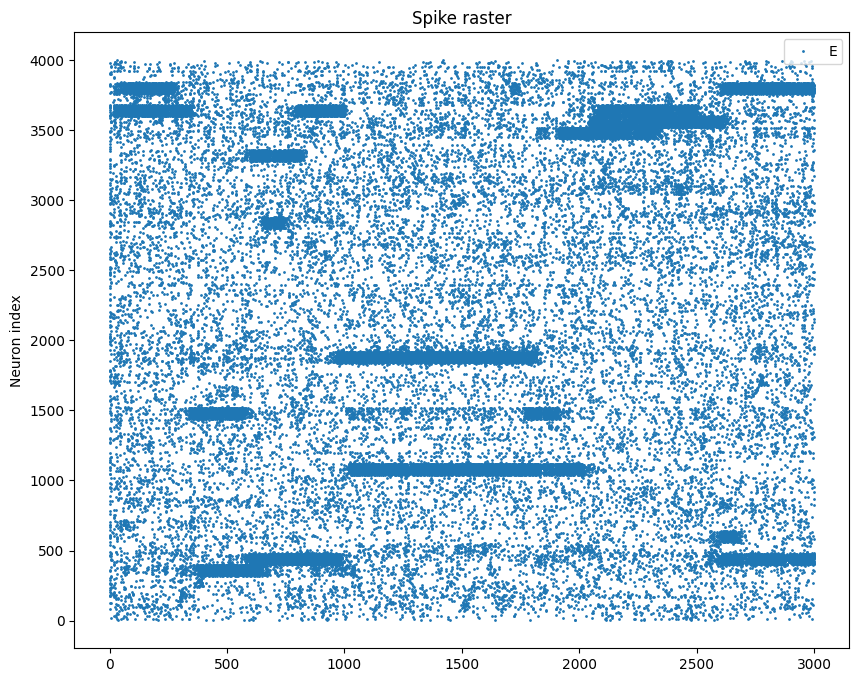

In [ ]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# --- Model parameters ---
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)
rng = params.get_rng()

# Unpack scaled weights
j_ee, j_ei, j_ie, j_ii = params.scaled_weights
tau1 = params.tau1

# Set up equations
eqs_base = """
dV/dt = (mu - V) / tau_m + Isyn : 1 (unless refractory)
Isyn = g : 1/second
dg/dt = (x - g) / tau_2 : 1/second
dx/dt = -x / tau_1 : 1/second

mu : 1      # per-neuron bias (external input)
tau_m : second  # per-neuron membrane time constant
tau_1 : second # varies depending on inhibitory or excitatory neuron
tau_2 : second # varies depending on inhibitory or excitatory neuron
"""

# Excitatory neurons include cluster_id for clustered connectivity
eqs_E = eqs_base + """
cluster_id : integer (constant)  # cluster membership for E->E clustering
"""

# Excitatory population
E = NeuronGroup(
    params.N_E,
    eqs_E,
    threshold=f'V > {params.Vt}',
    reset=f'V = {params.Vr}',
    refractory=params.refractory_t,
    method='euler',
    dt=params.dt
)
# Inhibitory population
I = NeuronGroup(
    params.N_I,
    eqs_base,
    threshold=f'V > {params.Vt}',
    reset=f'V = {params.Vr}',
    refractory=params.refractory_t,
    method='euler',
    dt=params.dt
)

# Set up bias and initial voltages randomly 
E.mu = rng.uniform(*params.mu_e_range, size=params.N_E)
E.V = rng.uniform(params.Vr, params.Vt, size=params.N_E)
I.mu = rng.uniform(*params.mu_i_range, size=params.N_I)
I.V = rng.uniform(params.Vr, params.Vt, size=params.N_I)

# Set time constants
E.tau_m = params.tau_m_e
E.tau_1 = params.tau1
E.tau_2 = params.tau2_e
I.tau_m = params.tau_m_i
I.tau_1 = params.tau1
I.tau_2 = params.tau2_i


# Set up synapses for connections involving inhibitory neurons
S_ie = Synapses(E, I, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
# I -> E
S_ei = Synapses(I, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
# I -> I
S_ii = Synapses(I, I, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

# Connect inhibitory synapses (same probability for all)
S_ei.connect(p=params.p_conn_i)
S_ie.connect(p=params.p_conn_i)
S_ii.connect(p=params.p_conn_i)

S_ie.w = j_ie
S_ei.w = j_ei
S_ii.w = j_ii

# E -> E connections: handle clustering if enabled
# Uses a single Synapses object with cluster-aware connectivity

if cluster_params.enabled:
    S_ee_in = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
    S_ee_out = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

    p_in, p_out = cluster_params.calculate_p_in_out(params.N_E, params.p_conn_e)
    
    # Connect with different probabilities based on cluster membership

    S_ee_in.connect(
        condition='i // cluster_size == j // cluster_size',
        p='p_in',  
        namespace={'p_in': p_in, 'p_out': p_out, 'cluster_size': cluster_params.cluster_size}
    )

    S_ee_out.connect(
        condition='i // cluster_size != j // cluster_size',
        p='p_out', # 
        namespace={'p_in': p_in, 'p_out': p_out, 'cluster_size': cluster_params.cluster_size}
    )
    
    # Set weights: stronger for within-cluster, baseline for between-cluster
    # same_cluster = (E.cluster_id[S_ee_in.i] == E.cluster_id[S_ee_in.j])
    S_ee_in.w = j_ee * cluster_params.weight_scaling_factor
    S_ee_out.w = j_ee
else:
    S_ee = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

    # No clustering: uniform connectivity
    E.cluster_id = 0  # all neurons in "cluster 0"
    S_ee.connect(condition='i != j', p=params.p_conn_e)
    S_ee.w = j_ee

# --- Monitors ---
M_E = StateMonitor(E, variables=['V', 'x'], record=True)
M_I = StateMonitor(I, variables=['V', 'x'], record=True)
spk_E = SpikeMonitor(E)
spk_I = SpikeMonitor(I)

run(params.duration)

# Plot the Spike Raster and Membrane Potential for a few Neurons

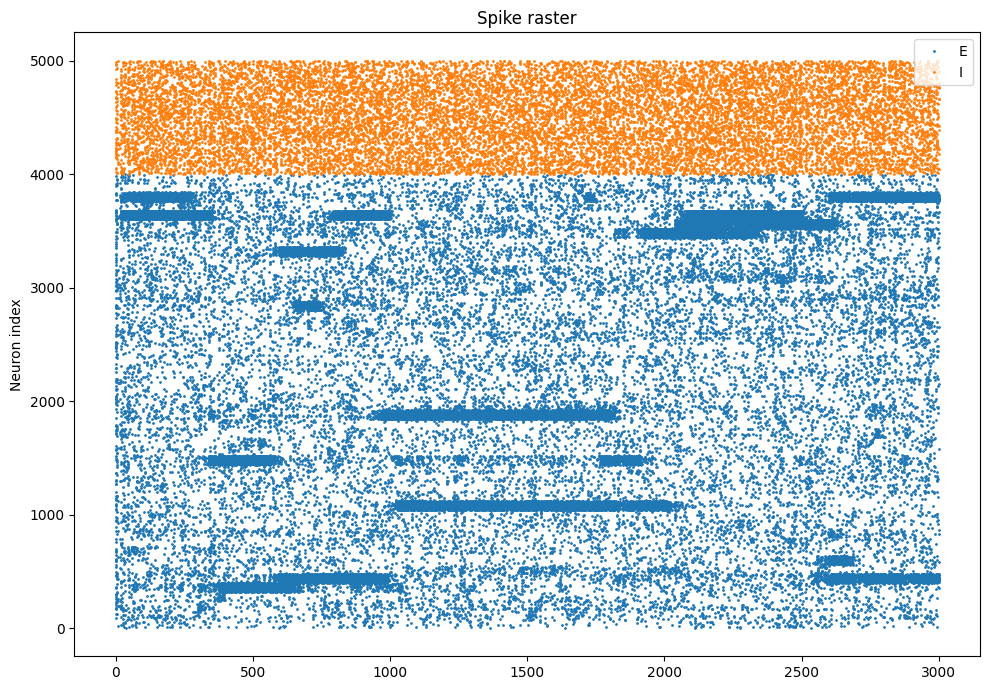

In [111]:
fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

# Raster plot
axes.plot(spk_E.t/ms, spk_E.i, '.', markersize=2, label='E')
axes.plot(spk_I.t/ms, spk_I.i + params.N_E, '.', markersize=2, label='I')
axes.set_ylabel('Neuron index')
axes.set_title('Spike raster')
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the membrane potentials of a few neurons

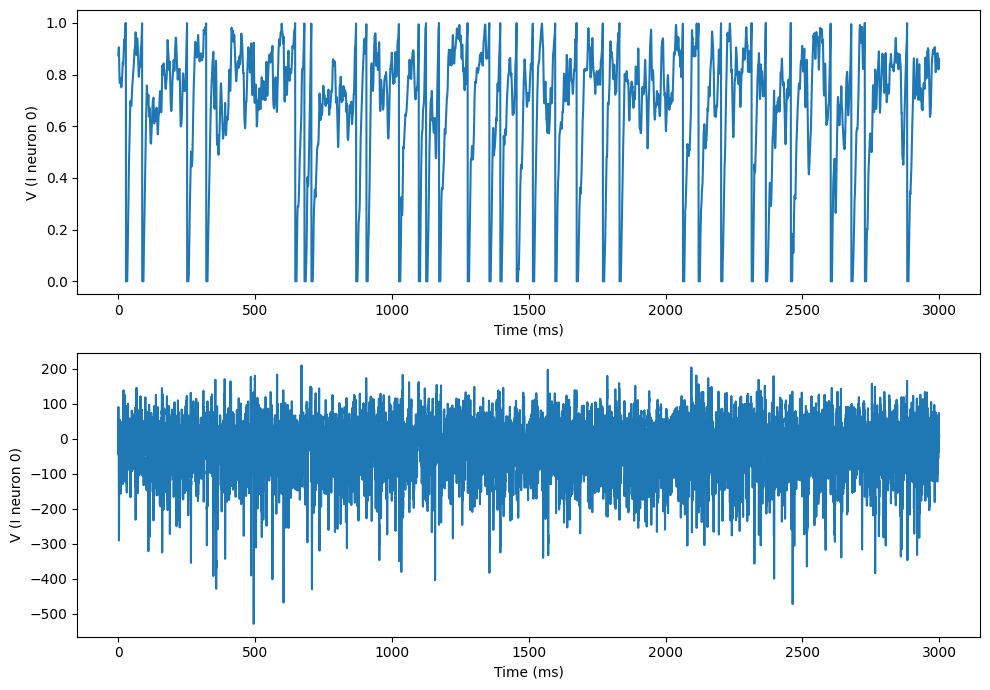

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(M_E.t/ms, M_I.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(M_E.t/ms, M_I.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

In [39]:
def firing_rate(spike_monitor, num_in_population, start_t, window_t):
    # The paper only counts spikes after 1.5s, and looks for 1.5s - we do the same
    mask = (spike_monitor.t >= start_t) & (spike_monitor.t <= start_t + window_t)
    spikes = spike_monitor.i[mask]
    # For each neuron in the population (minlength is set), count the spikes
    spike_counts = np.bincount(spikes, minlength=num_in_population)
    # Return a simple time averaged calculation of firing rate
    return spike_counts / window_t

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)


Text(0.5, 1.0, 'Firing Rate for Unclustered Network')

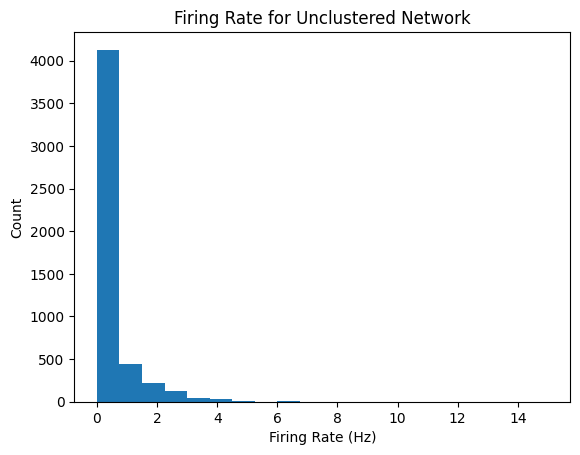

In [ ]:
firing_rates_e = firing_rate(spk_E, params.N_E, params.analysis_start_t, params.analysis_window_t)
firing_rates_i = firing_rate(spk_I, params.N_I, params.analysis_start_t, params.analysis_window_t)
print(firing_rates_e.shape, firing_rates_i.shape)
firing_rates = np.concatenate([firing_rates_e, firing_rates_i])
print(firing_rates.shape)

fig, ax = plt.subplots()

ax.hist(firing_rates, bins=20, range=(0,15))
ax.set_xlabel('Firing Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title("Firing Rate for Unclustered Network")

In [25]:
class NeuronNetwork():
    def __init__(self, params: ModelParams, clustering_params: ClusterParams):
        self.params = params
        self._initialize()

    def _initialize(self):
        pass

    def run(self):
        pass

    def firing_rate(self):
        pass

    def spikes(self):
        pass

    